In [1]:
# This is a self-check project on the content of Sutton's introductory RL book: http://incompleteideas.net/book/the-book-2nd.html

In [2]:
# The goal is to build a simple AI agent able to play Tic Tac Toe game without prior instructions.

In [3]:
# No dedicated RL libraries are used, only the standard lib + numpy for numerical work, as a challange
import numpy as np
import itertools
import random as rand
from datetime import datetime

In [4]:
# The training of the model is based on self-play and tabular-search method, where said table serves as the reward function
# that guides our agent, and which is learned through iterative simulation of the game.

In [5]:
# We do that, by letting the two players try different strategies in each round.
# They do so, by greedily choosing the ones with the highest win% in 9/10 cases, and through exploration, where they choose a 
# completely random move in 1/10 cases. It's crucial since moves are obviously dependant of each other, thus some low win%
# moves might prove profitable in the future, if they lead to some other, significantly better states of the game. 

From "Reinforcement learning: an introduction"
by Sutton and Barto 
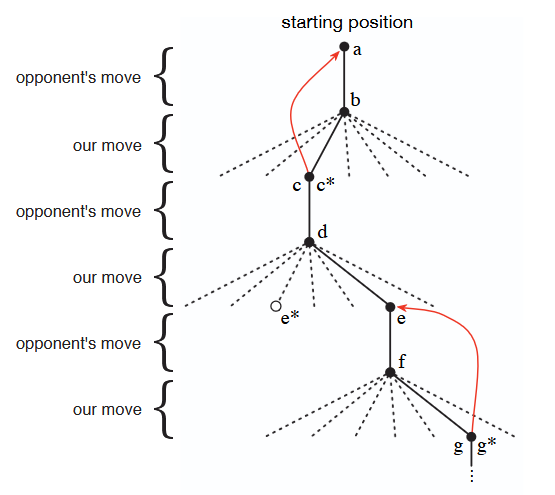

In [6]:
# We start by defining the two players
agent = 'x'
opponent = 'o'

In [7]:
# To initialize our table, we create a list of all possible board states through simple combinatorics and filtering
all_variations = list(itertools.product(['x', 'o', 'blank'], repeat=9))
valid_boards = [
    v for v in all_variations
    if abs(v.count('x') - v.count('o')) <= 1
]

In [8]:
# Let's evaluate the states, by (roughly) assigning the probabilities of winning the game associated with said states
def check_status(board_tuple, player, adversary):
    board = np.array(board_tuple, dtype=str).reshape(3, 3)
    # Possible winning combinations
    combinations_to_check = [
        ((0,0),(0,1),(0,2)), ((1,0),(1,1),(1,2)), ((2,0),(2,1),(2,2)),
        ((0,0),(1,0),(2,0)), ((0,1),(1,1),(2,1)), ((0,2),(1,2),(2,2)),
        ((0,0),(1,1),(2,2)), ((0,2),(1,1),(2,0))
    ]
    """
     If the board state won is give it reward/win% == 1
     If lost == 0
     Else win% ==  0.1 (Pesimistic initial values)
     Why pesimistic?
     We want the reward value to "flow" as fast as
     possible from the 100% winning stats in the late rounds 
     to the earlier states, but gradually slow down towards the 
     early states, which are naturally more "uncertain" to evaluate
    """
    for stc in combinations_to_check:
        values = [board[i, j] for i, j in stc] # Get values
        if all(v == player for v in values):
            return 1.0 # win
        if all(v == adversary for v in values):
            return 0.0 # lose
    return 0.1 # neither

table_agent = {board: check_status(board, agent, opponent) for board in valid_boards}
table_opponent = {board: check_status(board, opponent, agent) for board in valid_boards}
table = {agent: table_agent, opponent: table_opponent}

In [9]:
# We have the policy table -> time for a training loop
"""
1) Start with matrix [0 = blank]: 
    0 0 0 
    0 0 0 
    0 0 0  
2) Pick the highest win% valid next move from the table in 9/10 cases
3) Pick random move in 1/10 cases
4) Compare the rewards between current and previous move
5) Update the previous move based on the updated win%
6) Play till someone wins or the space runs out  
7) NEW EPPISODE (as defined ^)
8) Continue as long as necessary  
"""
# Training parameters
episodes = 50_000
learning_rate = 0.1
exploration_rate = 0.1

In [10]:
# We define a single move of an agent, accordingly to described logic
def move(player):
    # Get the possible next moves
    global round, current_state
    blank_indexes = [i for i, x in enumerate(current_state) if x == 'blank']
    possible_states = [[player if i == b_i else x for i, x in enumerate(current_state)] 
                       for b_i in blank_indexes]
    #  Main space search idea: exploitation / exploration tradeoff 
    roll = rand.uniform(0,1)
    if roll >= exploration_rate:
        new_state = max(possible_states, key=lambda p_s: table[player][tuple(p_s)])
    else:
        new_state = rand.choice(possible_states)
    current_state = new_state

In [11]:
# Training the model part
pre_train_time = (datetime.now())
for ep in range(episodes):
    if ep % 100000 == 0 and ep > 0:
        learning_rate *= 0.9 # Small learning rate decay 
        print(f'Episode: {ep}/{episodes}')
        print(f'Training time: {datetime.now() - pre_train_time}')
        print(f'Progress: {ep/episodes}%')
    # Initialize board
    current_state = ['blank' for i in range(9)]
    agent_prev_state = None
    opponent_prev_state = None
    
    while True:
        move(agent) # Agent move
        # !Important! : update the last state evaluation AFTER the move of the opponent
        # Initially it was set update instantly after own move, but this leads
        # to updating actions independent of the player
        # since current state is variable is modified by enemy's move
        if agent_prev_state is not None:
            table[agent][tuple(agent_prev_state)] += learning_rate * (
                table[agent][tuple(current_state)] - table[agent][tuple(agent_prev_state)]
            )
        # Save for later
        agent_prev_state = current_state.copy()
        # 3. Check Win/Loss/Draw
        if table[agent][tuple(current_state)] == 1:
            # Punish (without explicit punish, the game stops, and thus 
            # enemy never actually learns from "giving" a win to the opponent)
            if opponent_prev_state is not None:
                table[opponent][tuple(opponent_prev_state)] += learning_rate * (
                    0.0 - table[opponent][tuple(opponent_prev_state)]
                )
            break
        if 'blank' not in current_state:
            break

        move(opponent) # Oppo turn
        if opponent_prev_state is not None:
            table[opponent][tuple(opponent_prev_state)] += learning_rate * (
                table[opponent][tuple(current_state)] - table[opponent][tuple(opponent_prev_state)]
            )  
        opponent_prev_state = current_state.copy()
        if table[opponent][tuple(current_state)] == 1:
            if agent_prev_state is not None:
                table[agent][tuple(agent_prev_state)] += learning_rate * (
                    0.0 - table[agent][tuple(agent_prev_state)]
                )
            break
        if 'blank' not in current_state:
            break

In [12]:
# Playing-out-the-game logic
def print_board(state):
    symbols = {'x': 'X', 'o': 'O', 'blank': '.'}
    board = [symbols[s] for s in state]
    print(f"\n {board[0]} | {board[1]} | {board[2]}")
    print(f"---|---|---")
    print(f" {board[3]} | {board[4]} | {board[5]}")
    print(f"---|---|---")
    print(f" {board[6]} | {board[7]} | {board[8]}")
    print()

def human_move(state):
    blank_indexes = [i for i, x in enumerate(state) if x == 'blank']
    while True:
        try:
            idx = int(input("Your move (1-9): ")) - 1
            if idx in blank_indexes:
                state[idx] = opponent
                return state
            else:
                print("Invalid move, try again.")
        except ValueError:
            print("Enter a number between 1 and 9.")

def check_winner(state):
    combos = [
        (0,1,2),(3,4,5),(6,7,8),
        (0,3,6),(1,4,7),(2,5,8),
        (0,4,8),(2,4,6)
    ]
    for a,b,c in combos:
        if state[a] == state[b] == state[c] != 'blank':
            return state[a]
    if 'blank' not in state:
        return 'draw'
    return None

In [13]:
# The actual game
print("\nBoard positions:")
print(" 1 | 2 | 3")
print("---|---|---")
print(" 4 | 5 | 6")
print("---|---|---")
print(" 7 | 8 | 9")

current_state = ['blank'] * 9
round = 1
just_played = agent
exploration_rate = 0

while True:
    # Agent moves
    move(agent)
    print_board(current_state)
    winner = check_winner(current_state)
    if winner:
        print("Agent wins!" if winner == agent else "Draw!")
        break

    # Human moves
    current_state = human_move(current_state)
    print_board(current_state)
    winner = check_winner(current_state)
    if winner:
        print("You win!" if winner == opponent else "Draw!")
        break


Board positions:
 1 | 2 | 3
---|---|---
 4 | 5 | 6
---|---|---
 7 | 8 | 9

 . | . | X
---|---|---
 . | . | .
---|---|---
 . | . | .



Your move (1-9):  7



 . | . | X
---|---|---
 . | . | .
---|---|---
 O | . | .


 . | . | X
---|---|---
 . | . | .
---|---|---
 O | . | X



Your move (1-9):  6



 . | . | X
---|---|---
 . | . | O
---|---|---
 O | . | X


 X | . | X
---|---|---
 . | . | O
---|---|---
 O | . | X



Your move (1-9):  5



 X | . | X
---|---|---
 . | O | O
---|---|---
 O | . | X


 X | X | X
---|---|---
 . | O | O
---|---|---
 O | . | X

Agent wins!
